In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from plottr.data.datadict_storage import datadict_from_hdf5
import lmfit

In [3]:
from sequence_parser import Sequence, Variable, Variables
from sequence_parser.iq_port import Port
from sequence_parser.instruction import *

In [4]:
readout_freq = 10.306
readout_lo_freq = 10.423 # 10.387
readout_if_freq = readout_lo_freq - readout_freq
JPA_if_freq = readout_freq * 2 - readout_lo_freq * 2

qubit_lo_freq = 7.85
ge_freq = 8.03+0.0051-0.00017#8.02-0.00233#7.42
anharmonicity = -318e-3-0.00081-0.00056
ge_if_freq = ge_freq-qubit_lo_freq
print(ge_freq, anharmonicity)

fogi_lo_freq = 2 * qubit_lo_freq - readout_lo_freq# - 1/ 100000#5.35
fogi_freq = 5.468 # amp=0.5
fogi_if_freq = -(fogi_freq - fogi_lo_freq )

8.03493 -0.31937


In [50]:
readout_lo_freq-10.299e9

124000000.0

## FFT

In [5]:
def FFT(x, y):
    off_ini = np.mean(y)
    y_mod = y - off_ini
    Y = np.abs(np.fft.fft(y_mod))
    dt = 2e-9
    N = len(y)
    t = x
    f = np.fft.fftfreq(N, dt)
    sorted_idx=np.argsort(f)
    x_fft = f[sorted_idx]
    y_fft = Y[sorted_idx]
    return x_fft, y_fft

In [6]:
def FFT_show(data, i):
    header = "D:/K_sunada/result/CDY152/"
    dd = datadict_from_hdf5(header+data+"/data")
    x = (dd['time']['values'])[i]
    y = (dd['waveform']['values'])[i] #- dd['waveform1']['values'] 
    readout_freq = 10.306e9
    readout_if_freq = (10.423-10.306)*1e9
    readout_lo_freq = readout_freq + readout_if_freq

    x_fft = FFT(x, y)[0]
    y_fft = FFT(x, y)[1]

    fig, (ax1, ax2) = plt.subplots(nrows=2)
    ax1.set_xlabel('Time (ns)')
    ax1.set_ylabel('Waveform (V)')
    ax1.plot(x,  y)
    # ax1.plot(x, np.abs(signal.hilbert(y)))
    ax1.tick_params(axis="x", direction="in")
    ax1.tick_params(axis="y", direction="in")

    ax2.set_xlabel('Frequency(Hz)')
    ax2.set_ylabel('Power (arb. u.)')
    ax2.plot(readout_lo_freq-x_fft, y_fft)
    
    ax2.tick_params(axis="x", direction="in")
    ax2.tick_params(axis="y", direction="in")
    # ax2.set_xlim(0, 250e6)
    ax2.set_xlim(readout_lo_freq-250e6, readout_lo_freq)
    peak = readout_lo_freq-x_fft[signal.argrelmax(y_fft, order=100)]

    plt.show()
    return peak, y


In [7]:
def waveform_show(data, i):
    header = "D:/K_sunada/result/CDY152/"
    dd = datadict_from_hdf5(header+data+"/data")
    x = dd['time']['values'][i]
    y = dd['waveform']['values'][i]# - dd['waveform1']['values']
    label = dd['fogi_frequency']['values'][i]

    plt.rcParams["font.size"] = 14
    fig, (ax1) = plt.subplots(nrows=1)
    ax1.set_xlabel('Time (ns)', size = "large")
    ax1.set_ylabel('Waveform (V)', size = "large")
    ax1.plot(x,  y)
    ax1.tick_params(axis="x", direction="in")
    ax1.tick_params(axis="y", direction="in")
    plt.tick_params(
                top='on',
                bottom='on`',
                left='on',
                right='on',
               )
    plt.show()
    return label


In [53]:
def LPF(x, samplerate, fp, fs, gpass, gstop):
    fn = samplerate/2
    wp = fp/fn
    ws = fs/fn
    N, Wn = signal.buttord(wp, ws, gpass, gstop)
    b, a = signal.butter(N, Wn, "low")
    y = signal.filtfilt(b, a, x)
    return y

## 12/13

In [325]:
def time_reverse(data, id,f_if, duration):
    dd = datadict_from_hdf5(header+data+"/data")
    x = dd['time']['values'][id][0:duration]
    y = dd['waveform']['values'][id][0:duration]
    y = y[::-1]
    y1 =  y* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
    y_LPF = np.array(np.abs(LPF(y1, 500e6, 10e6, 30e6, 5, 40))*2**0.5)

    x_comp = []
    y_comp = []
    for i in range(len(y_LPF)-1):
        x_comp.append(x[i])
        x_comp.append((x[i]+x[i+1])/2)
        y_comp.append(y_LPF[i])
        y_comp.append((y_LPF[i]+y_LPF[i+1])/2)
    x_comp.append(x[-1])
    x_comp.append(x[-1]+1)
    y_comp.append(y_LPF[-1])
    y_comp.append(y_LPF[-1])
    
    time = np.array(x_comp)
    control_pulse = np.array(y_comp) * np.cos(2*np.pi* f_if*(time*1e-9))
    return control_pulse 

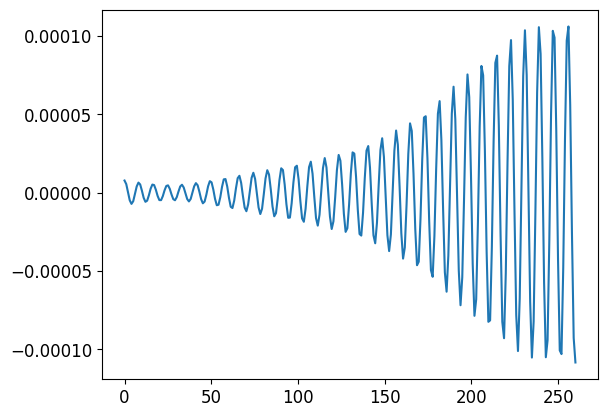

In [327]:
ph_data = "/2023-11-30/2023-11-30T104227_b7ed2f38-70_JPA_photon_generation"
y =time_reverse(ph_data, 7, 1.2173913e+08, 130)
plt.plot(np.linspace(0, 260, 260), y)

In [377]:
header = "D:/K_sunada/result/CDY152/"
data = "/2023-11-30/2023-11-30T104227_b7ed2f38-70_JPA_photon_generation"
dd = datadict_from_hdf5(header+data+"/data")
x = dd['time']['values'][7][0:130]
y = dd['waveform']['values'][7][0:130]
y = y[::-1]
x_fft = FFT(x, y)[0]
y_fft = FFT(x, y)[1]
peak = x_fft[signal.argrelmax(y_fft, order=50)]

y1 =  y* np.exp(-1j*2 *np.pi* 1.2173913e+08*(x*1e-9))
y_fft1 = FFT(x, y1)[1]
peak1 = x_fft[signal.argrelmax(y_fft1, order=50)]

y_LPF = LPF(y1, 500e6, 10e6, 30e6, 5, 40)
y_fft2 = FFT(x, y_LPF)[1]
peak2 = x_fft[signal.argrelmax(y_fft2, order=50)]

In [378]:
def time_reverse(data, id,f_if, duration):
    dd = datadict_from_hdf5(header+data+"/data")
    x = dd['time']['values'][id][0:duration]
    y = dd['waveform']['values'][id][0:duration]
    y = y[::-1]
    y1 =  y* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
    y_LPF = np.array(np.abs(LPF(y1, 500e6, 10e6, 30e6, 5, 40))*2**0.5)
    
    x_comp = []
    y_comp = []
    for i in range(len(y_LPF)-1):
        x_comp.append(x[i])
        x_comp.append((x[i]+x[i+1])/2)
        y_comp.append(y_LPF[i])
        y_comp.append((y_LPF[i]+y_LPF[i+1])/2)
    x_comp.append(x[-1])
    x_comp.append(x[-1]+1)
    y_comp.append(y_LPF[-1])
    y_comp.append(y_LPF[-1])
    time = np.array(x_comp)
    control_pulse = np.array(y_comp) * np.cos(2*np.pi* f_if*(time*1e-9))
    return control_pulse, np.array(y_comp), x_comp

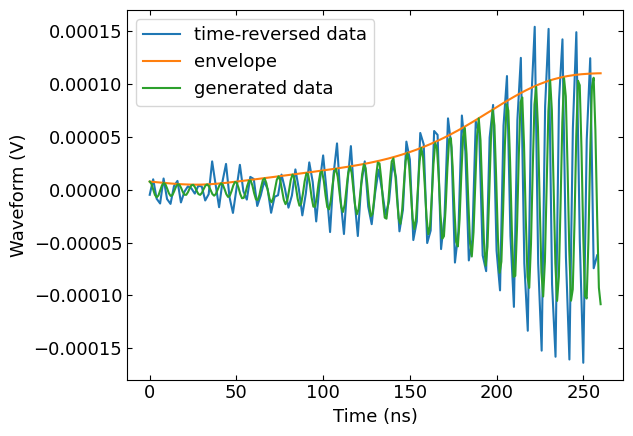

In [379]:
fig, ax0 = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on')
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel('Waveform (V)')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
plt.plot(x, y, label= "time-reversed data")

plt.plot(np.linspace(0, 260, 260),time_reverse(data, 7,1.2173913e+08, 130)[1], label="envelope")
plt.plot(np.linspace(0, 260, 260), time_reverse(data, 7,1.2173913e+08, 130)[0], label="generated data")
plt.legend()
plt.show()

## 12/15 photon number

In [403]:
from scipy.constants import *

In [499]:
def square(freq, amp, duration):
    x = np.linspace(0, duration-1, duration)
    y = amp* np.cos(2*np.pi* freq*(x*1e-9))
    env = np.zeros(duration) + amp
    return x, y, env

In [500]:
def photon_number(pulse, freq, atten_fixed, atten_fridge, atten_RT, sample_rate, P_vna):
    #pulse: [x, y, env], atten: dBm, samplerate: s, P_vna: W (when AWG amp=1.0)
    x = pulse[0]
    y = pulse[2] #env

    atten_W = 10**((atten_fixed + atten_fridge + atten_RT)/10)
    ene = 0
    for t in range(int(len(x)/sample_rate*1e-9)):
        ene = ene + (y[2*t]**2)*sample_rate

    return ene * P_vna * atten_W/ (2*np.pi*hbar*freq)


In [510]:
## square
ph_amp_id = 8
ph_amp = (1 + 0.5 * ph_amp_id) * 0.05
pulse = square(1.2173913e+08, ph_amp, 260)
rf_freq = readout_lo_freq-1.2173913e+08
atten_fixed = -52.1
atten_fridge = -20
atten_RT = -30
sample_rate = 2e-9
P_vna =  7.6e-6
photon_number(pulse, rf_freq, atten_fixed, atten_fridge, atten_RT, sample_rate,P_vna)

1.1156309210212658

In [515]:
def time_reverse(data, id,f_if, duration, awg):
    dd = datadict_from_hdf5(header+data+"/data")
    x = dd['time']['values'][id][0:duration]
    y = dd['waveform']['values'][id][0:duration]
    y = y[::-1]
    y1 =  y* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
    y_LPF = np.array(np.abs(LPF(y1, 500e6, 10e6, 30e6, 5, 40))*2**0.5)*awg
    
    x_comp = []
    y_comp = []
    for i in range(len(y_LPF)-1):
        x_comp.append(x[i])
        x_comp.append((x[i]+x[i+1])/2)
        y_comp.append(y_LPF[i])
        y_comp.append((y_LPF[i]+y_LPF[i+1])/2)
    x_comp.append(x[-1])
    x_comp.append(x[-1]+1)
    y_comp.append(y_LPF[-1])
    y_comp.append(y_LPF[-1])
    time = np.array(x_comp)
    control_pulse = np.array(y_comp) * np.cos(2*np.pi* f_if*(time*1e-9))
    return x_comp, control_pulse, np.array(y_comp)

In [529]:
## tr
data = "/2023-11-30/2023-11-30T104227_b7ed2f38-70_JPA_photon_generation"
data_id = 7
ph_amp_id = 8
ph_amp = (1000 + 4001/8 * ph_amp_id) 
pulse = time_reverse(data, data_id, 1.2173913e+08, 130, ph_amp)
rf_freq = readout_lo_freq-1.2173913e+08
atten_fixed = -52.1
atten_fridge = -20
atten_RT = -30
sample_rate = 2e-9
P_vna =  7.6e-6
photon_number(pulse, rf_freq, atten_fixed, atten_fridge, atten_RT, sample_rate,P_vna)
# plt.plot(pulse[0], pulse[1])
# plt.plot(pulse[0], pulse[2])


1.3840592405376964

In [ ]:
pn_squ = [0.0446, 0.1004, 0.1785, 0.2789, 0.4016, 0.5467, 0.7140, 0.9037, 1.1156]
pn_tr = [0.0553, 0.1245, 0.2214, 0.3460, 0.4982, 0.6782, 0.8858, 1.121, 1.384]

9.817479430199864e-12
0.003571402206012917


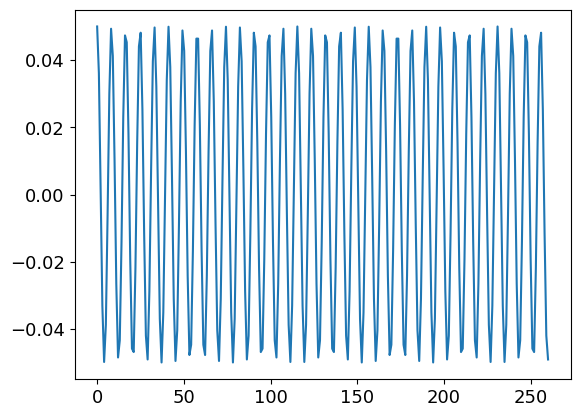

In [455]:
#square
ph_amp = 0 #0-8
freq_if = 1.2173913e+08
readout_lo_freq = 10.423e9
duration = 260
atten_dB = -60.08 -50 #fridge + attenuater + R.T. wiring
atten =  10**((atten_dB)/10)
x = np.linspace(0, duration, duration)
y = square(freq_if, (1 + 0.5 * ph_amp) * 0.05, duration)[1]
ene = 0
for t in range(int(duration/2)):
    ene = ene + (y[2*t]**2)*2e-9

P_vna = 7.6e-6
print(atten)
photon_number = ene*P_vna * atten/ (2*np.pi*hbar*(readout_lo_freq-freq_if))
plt.plot(x, y)
print(photon_number)

In [411]:
def watt_dbm(watt):
    return 10*np.log10(watt*1e3)

In [423]:
watt_dbm( 2.083596370665185e-16)

-126.8118640771921

In [421]:
10**((-21.2)/10)*1e-3, 10**((-23.1)/10)  *1e-3/(0.8)**2

(7.5857757502918365e-06, 7.652794052631969e-06)

array([-61538461.53846154,  61538461.53846154])

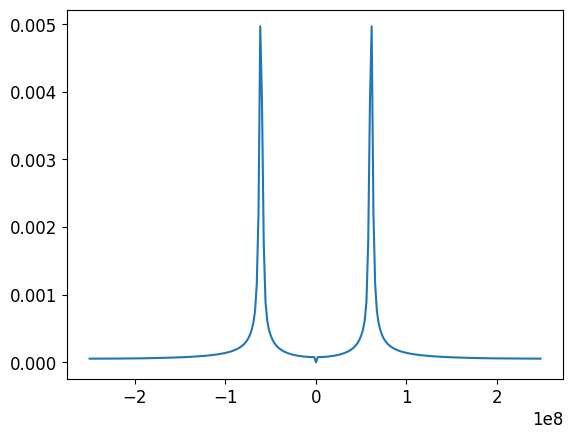

In [354]:
x_fft = FFT(x, y)[0]
y_fft = FFT(x, y)[1]

x_fft1 = FFT(np.linspace(0, 260, 260), time_reverse(data, 7,1.2173913e+08, 130)[0])[0]
y_fft1 = FFT(np.linspace(0, 260, 260), time_reverse(data, 7,1.2173913e+08, 130)[0])[1]
peak1 = x_fft1[signal.argrelmax(y_fft1, order=50)]
plt.plot(x_fft, y_fft1)
peak1

In [279]:
def Dephase(delay, amp, gamma, const):
    return amp*np.exp(-gamma*delay) + const

In [280]:
x_t1 = dd['time']['values'][7]
y_t1 = dd['waveform']['values'][7]

In [281]:
par_ini_t1 = {'gamma': 1/40000,'amp':15,'const':0}
par_min_t1 = {'gamma': 0,'amp':0,'const':-np.inf}
par_max_t1 = {'gamma': np.inf,'amp':np.inf,'const':np.inf,}
par_vary_t1 = {'gamma': True,'amp':True,'const':True}

model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t1[name],
    min = par_min_t1[name],
    max = par_max_t1[name],
    vary = par_vary_t1[name]
    )
result_t1 = model.fit(data = np.abs(y_t1), params = params, delay = x_t1)
result_t1

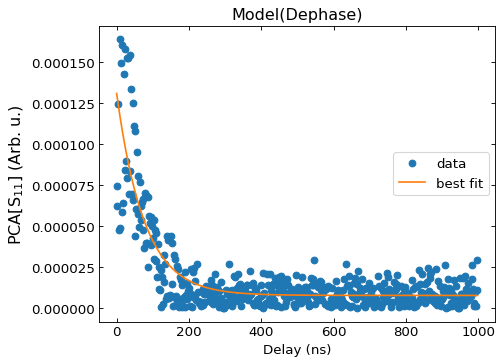

In [282]:
fig, (ax) = plt.subplots(dpi=80)
plt.rcParams["font.size"] = 12
plt.tick_params(top='on',bottom='on',left='on',right='on',)

result_t1.plot_fit(ax = ax)
# plt.plot(x_t1,result_t1.init_fit, label='init fit')
# ax.set_ylim(-8, 15)
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
ax.set_xlabel('Delay (ns)')#, size='large')
ax.set_ylabel('PCA[S$_{11}$] (Arb. u.)', size='large')

plt.legend(loc=7)
plt.show()

In [283]:
3*(1/0.01308351)*1e-9

2.292962668274798e-07

In [288]:
peak, peak1, peak2

(array([-1.2173913e+08,  1.2173913e+08]),
 array([-4347826.08695652]),
 array([-4347826.08695652]))

In [266]:
readout_lo_freq - 1.24e+08

10299000000.0

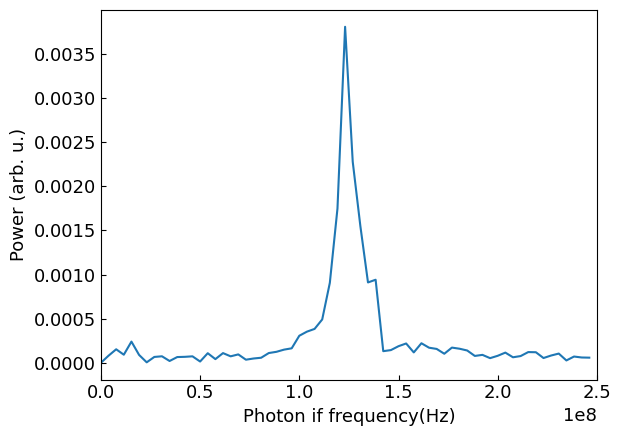

In [388]:
fig, ax2 = plt.subplots(nrows=1)

ax2.set_xlabel('Photon if frequency(Hz)')
ax2.set_ylabel('Power (arb. u.)')
ax2.plot(x_fft, y_fft)
# ax2.plot(x_fft, y_fft1)
# ax2.plot(x_fft, y_fft2)

ax2.tick_params(axis="x", direction="in")
ax2.tick_params(axis="y", direction="in")
ax2.set_xlim(0, 250e6)
# ax2.set_xlim(readout_lo_freq-250e6, readout_lo_freq)
peak = readout_lo_freq-x_fft[signal.argrelmax(y_fft, order=100)]

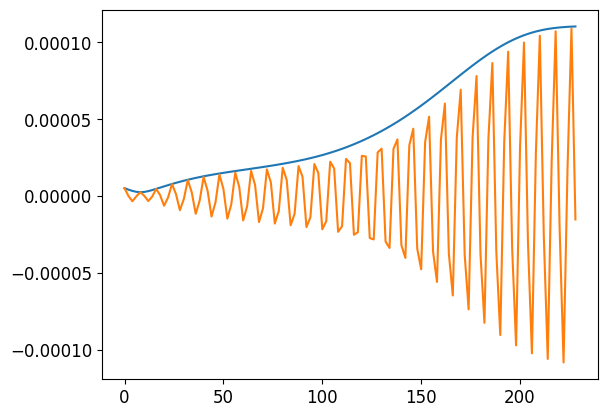

115


In [299]:
# plt.plot(x, y)
plt.plot(x, np.abs(y_LPF)*2**0.5)
plt.plot(x, np.abs(y_LPF)*2**0.5* np.cos(2*np.pi*1.24e+08*(x*1e-9)))
plt.show()
print(len(y_LPF))

## 12/4

1000
[1.0355e+10] 1000


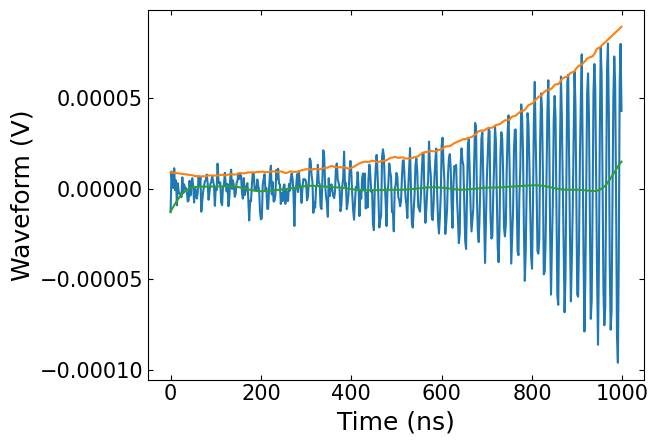

In [141]:
header = "D:/K_sunada/result/CDY152/"
data = "/2023-11-30/2023-11-30T104227_b7ed2f38-70_JPA_photon_generation"
dd = datadict_from_hdf5(header+data+"/data")
x = dd['time']['values'][1]
y = dd['waveform']['values'][1]
y = y[::-1]
y_env = np.abs(signal.hilbert(y))
y_env_smooth = signal.savgol_filter(y_env, 51, 1)
y_env_smooth1 = LPF(y, 500e6, 20e6, 50e6, 20, 40)
y_comp = []
for i in range(len(y_env_smooth)-1):
    y_comp.append(y_env_smooth[i])
    y_comp.append((y_env_smooth[i]+y_env_smooth[i+1])/2)
y_comp.append(y_env_smooth[-1])
y_comp.append(y_env_smooth[-1])
print(len(y_comp))

readout_freq = 10.306e9
readout_if_freq = (10.423-10.306)*1e9
readout_lo_freq = readout_freq + readout_if_freq

x_fft = FFT(x, y)[0]
y_fft = FFT(x, y)[1]
peak = x_fft[signal.argrelmax(y_fft, order=200)]
control_pulse = y_env_smooth * np.cos(2*np.pi* 67999999.99999999*(x*1e-9))

time = np.linspace(0, 999, 1000)
control_pulse1 = y_comp * np.cos(2*np.pi* peak*(time*1e-9))

print(readout_lo_freq- peak, len(y_comp))

fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
ax1.set_xlabel('Time (ns)', size='large')
ax1.set_ylabel('Waveform (V)', size='large')
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")
plt.tick_params(top='on',bottom='on`',left='on',right='on',)

# plt.plot(time, control_pulse1)
plt.plot(x, y)
plt.plot(x, y_env_smooth)
plt.plot(x, y_env_smooth1)

1000
[1.0533e+10 1.0313e+10] 1000


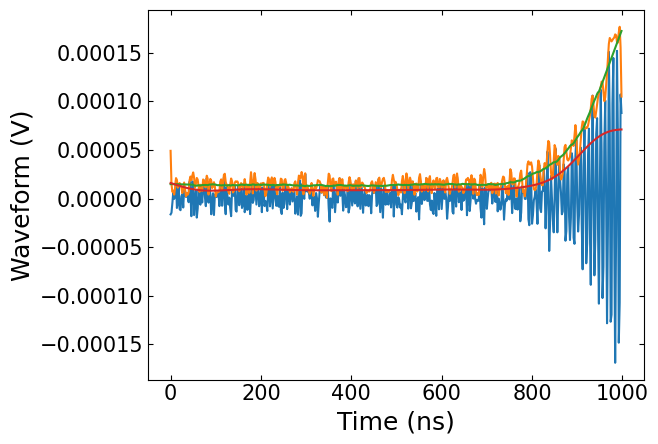

In [138]:
## on reso
header = "D:/K_sunada/result/CDY152/"
data = "/2023-11-30/2023-11-30T104227_b7ed2f38-70_JPA_photon_generation"
dd = datadict_from_hdf5(header+data+"/data")
x = dd['time']['values'][6]
y = dd['waveform']['values'][6]
y = y[::-1]
y_env = np.abs(signal.hilbert(y))
y_env_smooth = signal.savgol_filter(y_env, 51, 1)
y_env_smooth1 = LPF(np.abs(y), 500e6, 10e6 , 20e6, 20, 40)
y_comp = []
for i in range(len(y_env_smooth)-1):
    y_comp.append(y_env_smooth[i])
    y_comp.append((y_env_smooth[i]+y_env_smooth[i+1])/2)
y_comp.append(y_env_smooth[-1])
y_comp.append(y_env_smooth[-1])
print(len(y_comp))

readout_freq = 10.306e9
readout_if_freq = (10.423-10.306)*1e9
readout_lo_freq = readout_freq + readout_if_freq

# x_fft = FFT(x, y)[0]
# y_fft = FFT(x, y)[1]
# peak = x_fft[signal.argrelmax(y_fft, order=200)]
# control_pulse = y_env_smooth * np.cos(2*np.pi* 67999999.99999999*(x*1e-9))

# time = np.linspace(0, 999, 1000)
# control_pulse1 = y_comp * np.cos(2*np.pi* peak*(time*1e-9))

print(readout_lo_freq- peak, len(y_comp))

fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
ax1.set_xlabel('Time (ns)', size='large')
ax1.set_ylabel('Waveform (V)', size='large')
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")
plt.tick_params(top='on',bottom='on`',left='on',right='on',)

# plt.plot(time, control_pulse1)
plt.plot(x, y)
plt.plot(x, y_env)
plt.plot(x, y_env_smooth)
plt.plot(x, y_env_smooth1)

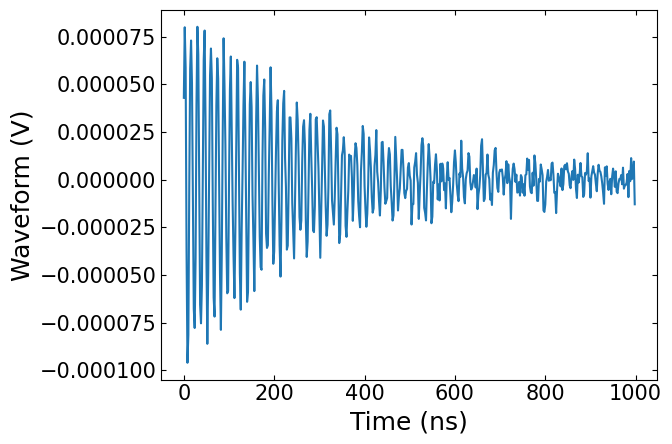

In [45]:
header = "D:/K_sunada/result/CDY152/"
data = "/2023-11-30/2023-11-30T104227_b7ed2f38-70_JPA_photon_generation"
dd = datadict_from_hdf5(header+data+"/data")
x = dd['time']['values'][1]
y = dd['waveform']['values'][1]

fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
ax1.set_xlabel('Time (ns)', size='large')
ax1.set_ylabel('Waveform (V)', size='large')

ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")
# ax1.set_xlim(0, 250000)
# ax1.set_ylim(-48, 160)
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

plt.plot(x, y)
plt.show()

[1.04615e+10 1.03845e+10]


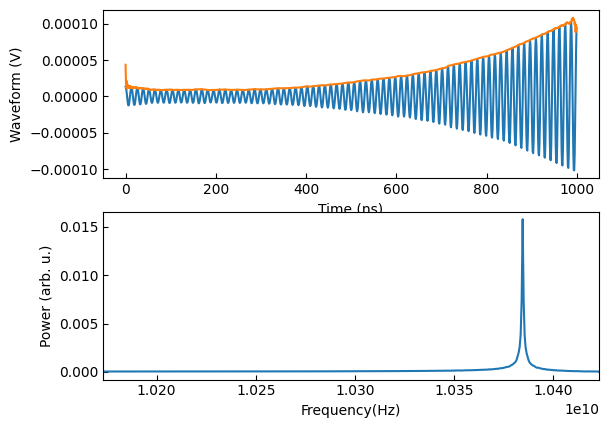

In [26]:
x = time
y = control_pulse1
readout_freq = 10.306e9
readout_if_freq = (10.423-10.306)*1e9
readout_lo_freq = readout_freq + readout_if_freq

x_fft = FFT(x, y)[0]
y_fft = FFT(x, y)[1]

fig, (ax1, ax2) = plt.subplots(nrows=2)
ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Waveform (V)')
ax1.plot(x,  y)
ax1.plot(x, np.abs(signal.hilbert(y)))
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")

ax2.set_xlabel('Frequency(Hz)')
ax2.set_ylabel('Power (arb. u.)')
ax2.plot(readout_lo_freq-x_fft, y_fft)

ax2.tick_params(axis="x", direction="in")
ax2.tick_params(axis="y", direction="in")
# ax2.set_xlim(0, 250e6)
ax2.set_xlim(readout_lo_freq-250e6, readout_lo_freq)
peak = readout_lo_freq-x_fft[signal.argrelmax(y_fft, order=100)]
print(peak)
plt.show()

In [48]:
readout_lo_freq-10.355e9

(68000000.0, 10423000000.0)